# Phase 2a-1. Macrophage subset & TAM subtype annotation

Phase 1에서 전체 폐암 scRNA-seq 데이터를 QC, normalization, HVG, PCA, Harmony, UMAP, Leiden, cell type annotation까지 완료했다.

이번 notebook의 목적은 전체 immune/TME cell 중 **Macrophage만 subset**한 뒤, macrophage 내부의 TAM subtype(C1QC+ TAM, SPP1+ TAM, ISG15+ TAM)을 marker gene 기반으로 확인하는 것이다.

핵심 질문:
- GSE127465 폐암 데이터에서도 논문에서 제시한 C1QC+ TAM / SPP1+ TAM 패턴이 보이는가?
- 단일 폐암 데이터에서 ISG15+ TAM도 독립적으로 분리되는가?


## 0. Helper — AnnData 상태 검증 함수

단순히 plot이 나오는지만 보는 것이 아니라, 각 단계에서 `adata/mac` 내부 상태가 의도대로 바뀌었는지 확인한다.

확인 항목:
- shape: 세포 수 × 유전자 수
- `X` type/dtype: sparse/float32 유지 여부
- `obs/var` unique: barcode/gene 중복 여부
- `obsm/obsp/uns`: PCA, UMAP, neighbors graph 저장 여부
- 주요 obs 컬럼 존재 여부


In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))
from utils.paths import *
from utils.report import ph2_report_adata_state

## 1. Phase 1 결과 불러오기

Phase 1에서 이미 전체 cell type annotation까지 완료한 `GSE127465_human_final.h5ad`를 불러온다.

여기서의 `cell_type`은 대분류 annotation이고, Phase 2에서는 Macrophage 내부를 다시 세분화해 `tam_subtype`을 추가한다.


In [2]:
adata = sc.read_h5ad(HUMAN_H5AD)
ph2_report_adata_state(adata, 'Phase 1 annotated data')
print(adata.obs['cell_type'].value_counts())

===== Phase 1 annotated data =====
shape: 44,860 cells x 2,000 genes
X type: <class 'numpy.ndarray'>
X dtype: float64
obs names unique: True
var names unique: True
obs columns: ['n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'n_counts', 'sample', 'leiden', 'cell_type']
obsm keys: ['X_pca', 'X_pca_harmony', 'X_umap']
obsp keys: ['connectivities', 'distances']
layers keys: ['counts']
uns keys: ['cell_type_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'sample_colors', 'umap']

cell_type
Unknown        15500
T cell         13474
Macrophage      8201
B cell          4608
Cancer cell     3077
Name: count, dtype: int64


## 2. 왜 Macrophage만 subset해서 재클러스터링하는가?

전체 cell 상태에서는 T cell, B cell, epithelial/tumor cell, macrophage 같은 큰 cell type 차이가 PCA/neighbor graph의 주요 variance를 차지한다.

하지만 Phase 2에서 보고 싶은 것은 macrophage 내부의 subtype 차이(C1QC+ TAM vs SPP1+ TAM)다. 전체 cell 기준 embedding에서는 이런 미세한 macrophage 내부 signal이 큰 cell type variance에 묻힐 수 있다.

따라서 Macrophage만 subset한 뒤 PCA/neighbor/UMAP/Leiden을 다시 수행하여 **macrophage 내부 구조에 최적화된 embedding space**를 새로 만든다.

단순히 전체 데이터에서 resolution만 올리는 방식은 graph 자체가 전체 cell 기준으로 만들어진 상태이기 때문에 noise cluster, fragmented cluster, meaningless tiny cluster를 늘릴 위험이 있다.


In [3]:
mac = adata[adata.obs['cell_type'] == 'Macrophage'].copy()
ph2_report_adata_state(mac, 'Macrophage subset')
print(mac.obs['cell_type'].value_counts())

===== Macrophage subset =====
shape: 8,201 cells x 2,000 genes
X type: <class 'numpy.ndarray'>
X dtype: float64
obs names unique: True
var names unique: True
obs columns: ['n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'n_counts', 'sample', 'leiden', 'cell_type']
obsm keys: ['X_pca', 'X_pca_harmony', 'X_umap']
obsp keys: ['connectivities', 'distances']
layers keys: ['counts']
uns keys: ['cell_type_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'sample_colors', 'umap']

cell_type
Macrophage    8201
Name: count, dtype: int64


## 3. Macrophage subset 재클러스터링

Phase 1에서 생성된 Harmony 보정 PCA embedding(`X_pca_harmony`)을 사용하여 macrophage subset 내부에서 neighbor graph를 다시 만든다.

주의:
- `neighbors`: 세포 간 graph 저장 단계
- `umap`: graph 기반 2D 시각화
- `leiden`: graph 기반 community detection으로 cluster label 생성


===== After macrophage reclustering =====
shape: 8,201 cells x 2,000 genes
X type: <class 'numpy.ndarray'>
X dtype: float64
obs names unique: True
var names unique: True
obs columns: ['n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'n_counts', 'sample', 'leiden', 'cell_type']
obsm keys: ['X_pca', 'X_pca_harmony', 'X_umap']
obsp keys: ['connectivities', 'distances']
layers keys: ['counts']
uns keys: ['cell_type_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'sample_colors', 'umap']

Leiden cluster count: 10
leiden
0    1543
1    1102
2    1025
3     987
4     927
5     701
6     671
7     605
8     602
9      38
Name: count, dtype: int64


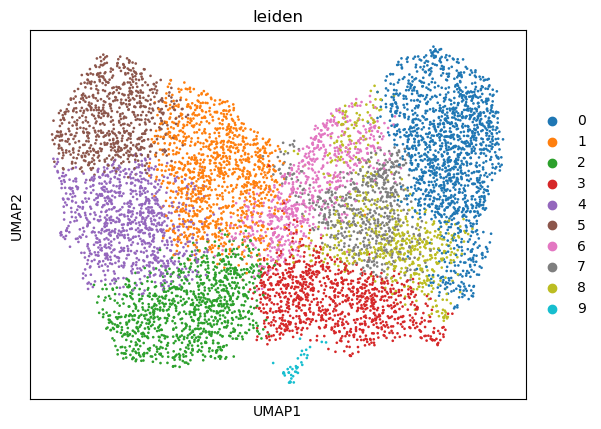

In [ ]:
sc.pp.neighbors(mac, use_rep='X_pca_harmony', n_pcs=17)
sc.tl.umap(mac, random_state=42)
sc.tl.leiden(mac, resolution=0.5)

ph2_report_adata_state(mac, 'After macrophage reclustering')
print('Leiden cluster count:', mac.obs['leiden'].nunique())
print(mac.obs['leiden'].value_counts().sort_index())

sc.pl.umap(mac, color='leiden')

## 4. TAM subtype marker gene 발현 확인

논문에서 제시한 TAM subtype marker를 기준으로 C1QC+ TAM, SPP1+ TAM, ISG15+ TAM이 macrophage subset 안에서 어디에 위치하는지 확인한다.

- C1QC: tissue-resident/homeostatic macrophage 계열 marker
- SPP1: tumor-associated remodeling / immunosuppressive macrophage 계열 marker
- ISG15: interferon-stimulated macrophage state marker

`use_raw=True`를 사용하여 HVG filtering 이후 사라졌을 수 있는 marker gene도 raw normalized matrix에서 조회할 수 있게 한다.

Missing markers in mac.raw: []


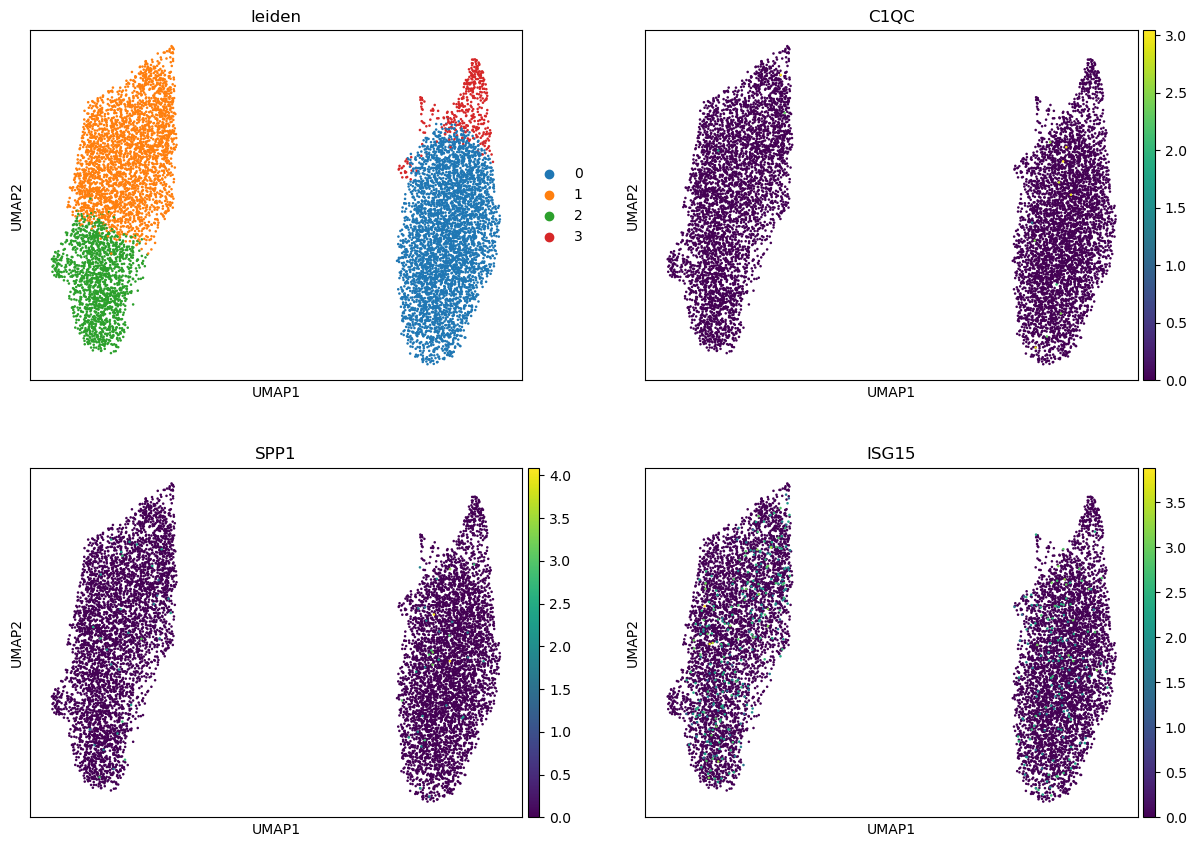

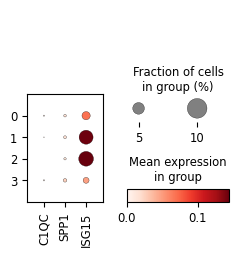

In [5]:
tam_markers = ['C1QC', 'SPP1', 'ISG15']
missing_markers = [g for g in tam_markers if g not in mac.raw.var_names]
print('Missing markers in mac.raw:', missing_markers)

sc.pl.umap(mac, color=['leiden', 'C1QC', 'SPP1', 'ISG15'], ncols=2, use_raw=True)
sc.pl.dotplot(mac, tam_markers, groupby='leiden', use_raw=True)

## 5. Marker 기반 TAM subtype annotation

UMAP과 dotplot을 함께 확인하여 marker 발현이 뚜렷한 cluster에 TAM subtype label을 부여한다.

현재 기준:
- cluster 3 → C1QC+ TAM
- cluster 0, 6 → SPP1+ TAM
- ISG15+ TAM은 단일 폐암 데이터에서 독립 cluster로 뚜렷하게 분리되지 않아 annotation하지 않음

이 결과는 C1QC+ TAM / SPP1+ TAM 패턴은 GSE127465 폐암 데이터에서도 관찰되지만, ISG15+ TAM은 pan-cancer 통합 수준에서 더 뚜렷할 수 있음을 시사한다.


tam_subtype
Unknown      4328
SPP1+ TAM    4167
C1QC+ TAM     394
Name: count, dtype: int64
tam_subtype
Unknown      48.69
SPP1+ TAM    46.88
C1QC+ TAM     4.43
Name: proportion, dtype: float64


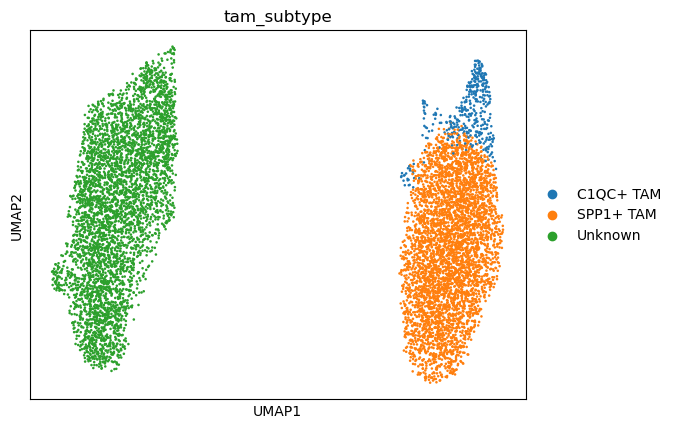

In [6]:
mac.obs['tam_subtype'] = mac.obs['leiden'].map({
    '3': 'C1QC+ TAM',
    '0': 'SPP1+ TAM',
    '6': 'SPP1+ TAM',
}).fillna('Unknown')

print(mac.obs['tam_subtype'].value_counts())
print((mac.obs['tam_subtype'].value_counts(normalize=True) * 100).round(2))

sc.pl.umap(mac, color='tam_subtype')

## 6. 중간 결과 저장

다음 notebook(`02_DEG_analysis.ipynb`)에서 DEG 분석을 수행하기 위해 TAM subtype annotation이 추가된 macrophage subset을 저장한다.

In [7]:
mac.write_h5ad(MAC_SUB_H5AD)
print(f'저장 완료: {MAC_SUB_H5AD}')

저장 완료: ../dataset/GSE127465_mac_subtyped.h5ad
